In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df=pd.read_csv("/content/drive/My Drive/Colab Notebooks/Machine Learning/house_price_dataset.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


In [6]:
df.shape

(500, 8)

In [7]:
df.describe()

,Area,Bedrooms,Bathrooms,Floors,Age,Parking,Distance_City,Price
count,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,5.000000e+02
mean,2381.492000,3.01000,2.468000,2.000000,17.490000,1.608000,14.709340,6.933517e+05
std,981.179041,1.39922,1.152229,0.820577,10.521564,1.144095,8.287714,2.490942e+05
min,610.000000,1.00000,1.000000,1.000000,0.000000,0.000000,1.130000,1.912408e+05
25%,1553.000000,2.00000,1.000000,1.000000,8.750000,1.000000,7.770000,4.836577e+05
50%,2417.000000,3.00000,2.000000,2.000000,18.000000,2.000000,14.055000,7.118018e+05
75%,3280.250000,4.00000,4.000000,3.000000,27.000000,3.000000,21.527500,9.141978e+05
max,3989.000000,5.00000,4.000000,3.000000,35.000000,3.000000,29.990000,1.134375e+06


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Area           500 non-null    int64  
 1   Bedrooms       500 non-null    int64  
 2   Bathrooms      500 non-null    int64  
 3   Floors         500 non-null    int64  
 4   Age            500 non-null    int64  
 5   Parking        500 non-null    int64  
 6   Distance_City  500 non-null    float64
 7   Price          500 non-null    float64
dtypes: float64(2), int64(6)
memory usage: 31.4 KB


In [9]:
df.isnull().sum()

,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
Age,0
Parking,0
Distance_City,0
Price,0


In [10]:
print("Number of duplicated rows: ",df.duplicated().sum())

Number of duplicated rows:  0


In [11]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,Age,Parking,Distance_City,Price
0,3219,1,1,3,17,1,7.47,875861.18
1,2833,1,4,1,1,0,7.34,787539.70
2,2669,5,1,3,12,3,7.39,793846.87
3,626,2,4,2,17,1,7.24,258571.69
4,3727,3,1,1,24,0,11.41,990079.87


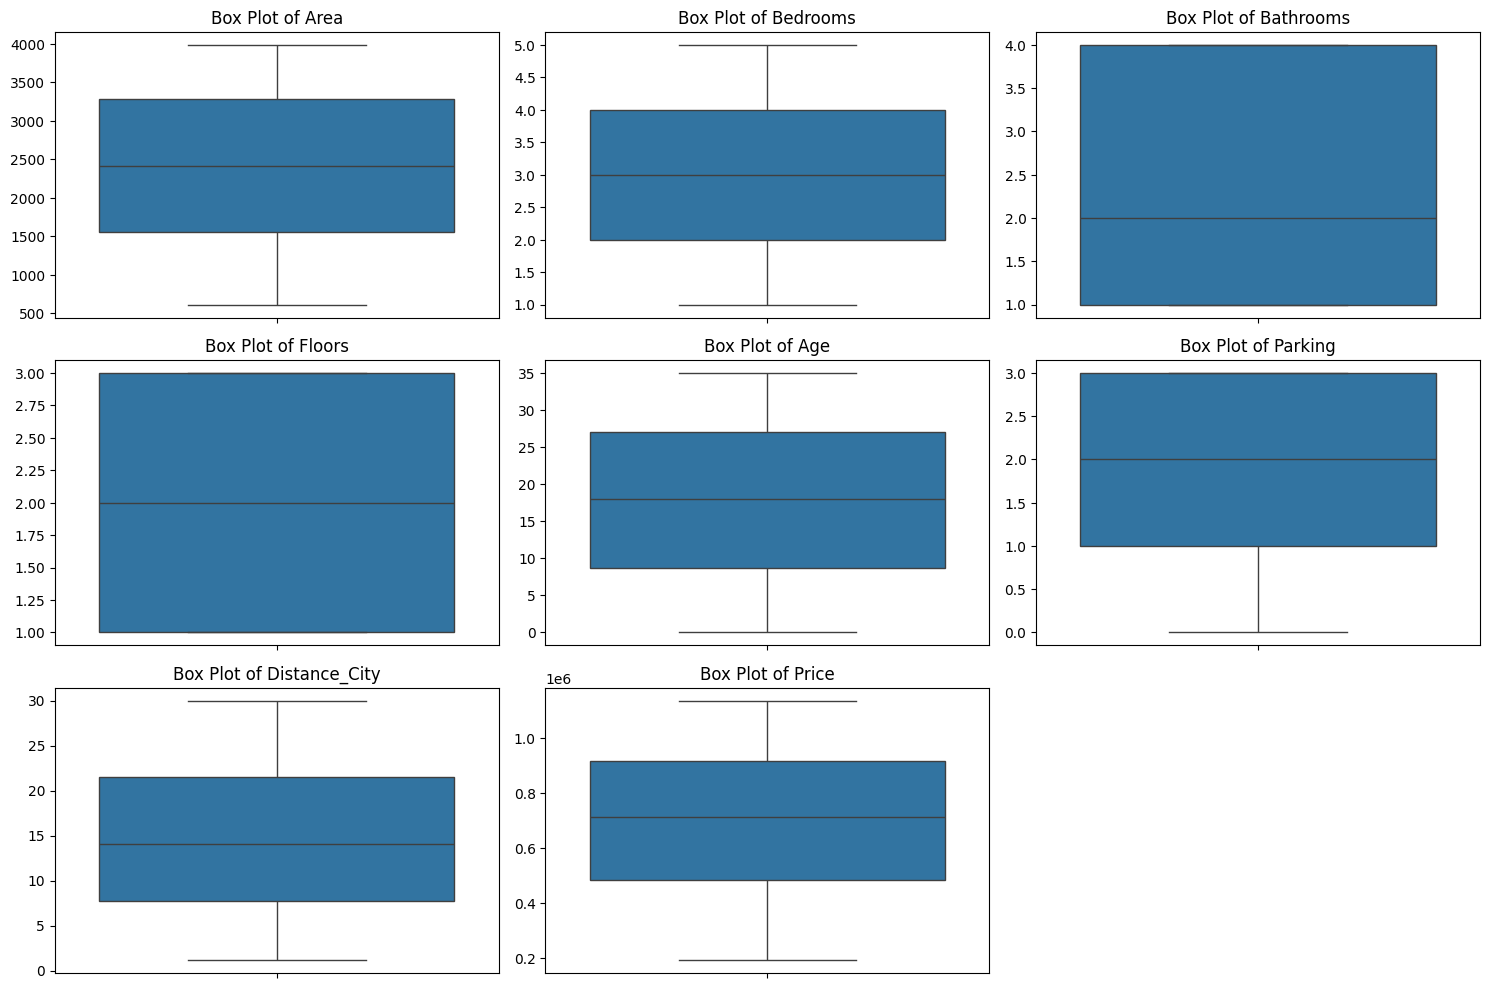

In [12]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_cols, 1):
    plt.subplot(len(numerical_cols) // 3 + 1, 3, i)
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

In [13]:
print(f"Shape of DataFrame before outlier removal: {df.shape}")

# Select only numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=np.number).columns

# Loop through each numerical column to find and remove outliers using IQR method
for column in numerical_cols:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Remove outliers
    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

print(f"Shape of DataFrame after outlier removal: {df.shape}")

Shape of DataFrame before outlier removal: (500, 8)
Shape of DataFrame after outlier removal: (500, 8)


In [14]:
df.columns

Index(['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'Age', 'Parking',
       'Distance_City', 'Price'],
      dtype='object')

In [15]:
x=df.iloc[:,0:-1]
x.head()

,Area,Bedrooms,Bathrooms,Floors,Age,Parking,Distance_City
0,3219,1,1,3,17,1,7.47
1,2833,1,4,1,1,0,7.34
2,2669,5,1,3,12,3,7.39
3,626,2,4,2,17,1,7.24
4,3727,3,1,1,24,0,11.41


In [16]:
y=df.iloc[:,-1]
y.head()

,Price
0,875861.18
1,787539.70
2,793846.87
3,258571.69
4,990079.87


In [17]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("Dateset is splitted for training and testing")

Dateset is splitted for training and testing


In [18]:
model=LinearRegression()
print("Model Created")

Model Created


In [19]:
model.fit(x_train,y_train)
print("Model is trained")

Model is trained


In [20]:
#Generate predictions for training and testing datasets using the trained model
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)
print("Predictions generated for both training and testing datasets")

Predictions generated for both training and testing datasets


In [21]:
#Metrics for training data
mae = mean_absolute_error(y_train, y_pred_train)
mse = mean_squared_error(y_train, y_pred_train)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred_train)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root MSE (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 12508.31494669888
Mean Squared Error (MSE): 238660362.33647603
Root MSE (RMSE): 15448.636261381651
R2 Score: 0.9960571088633137


In [22]:
#Metrics for testing data
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root MSE (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 11750.404842989949
Mean Squared Error (MSE): 217465105.79573894
Root MSE (RMSE): 14746.698131979882
R2 Score: 0.9967446556096432


In [23]:
model.coef_

array([  251.61701519, 14952.05259854, 10301.99785232,  8475.59749294,
        -894.62273299,  5149.58445162, -2369.77704149])

In [24]:
model.intercept_

np.float64(49398.661667761044)

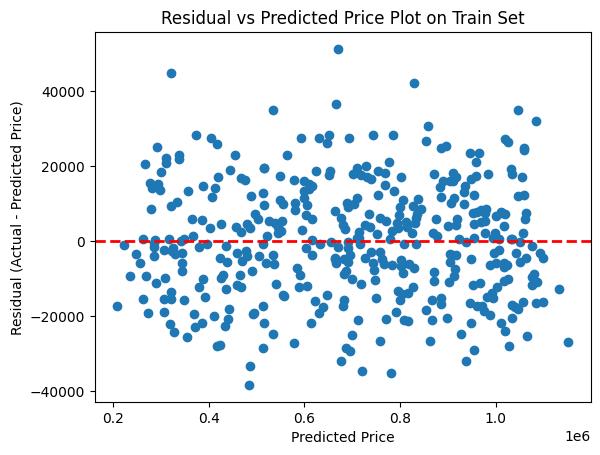

In [25]:
residuals = y_train - y_pred_train

plt.scatter(y_pred_train, residuals)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Price')
plt.ylabel('Residual (Actual - Predicted Price)')
plt.title('Residual vs Predicted Price Plot on Train Set')
plt.show()